This file contains all of the necessary code for analysis of our final project. 

Instructions:
- Run all
OR
- Run each cell individually

In [8]:
import sys
import subprocess
import pkgutil
import warnings

required_packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn"
]

def install_if_missing(package):
    if pkgutil.find_loader(package) is None:
        print(f"Installing missing package: {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    else:
        print(f"{package} already installed")

for pkg in required_packages:
    install_if_missing(pkg)

warnings.filterwarnings("ignore")

print("\n Ready")

pandas already installed
numpy already installed
matplotlib already installed
Installing missing package: scikit-learn

 Ready



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [9]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sk_silhouette

from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import KFold

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GroupShuffleSplit

AOI: HOSide
AOI: LOSide
0    378.0
1    378.0
2    378.0
3    378.0
4    378.0
Name: HOSide_GazeCount, dtype: float64
0    60.0
1    60.0
2    60.0
3    60.0
4    60.0
Name: LOSide_GazeCount, dtype: float64
0    1
1    1
2    1
3    1
4    1
Name: time_quartile, dtype: int64
1.8768024323429362
   gaze_covariance
0    -50894.185035
1    -50894.185035
2    -50894.185035
3    -50894.185035
4    -50894.185035


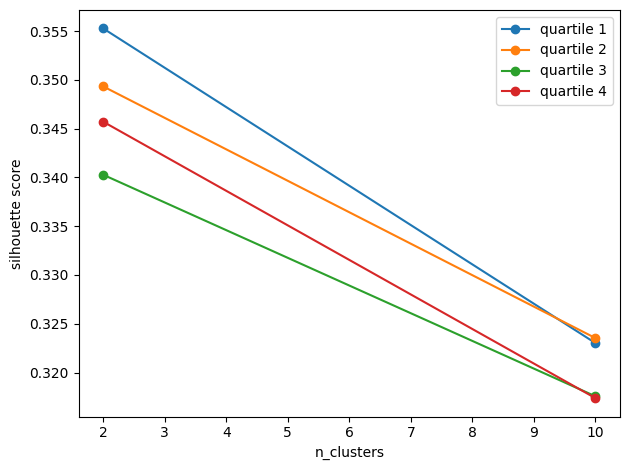

Best number of clusters per quartile:
   time_quartile  n_clusters  silhouette
0              1           2    0.355267
1              2           2    0.349324
2              3           2    0.340268
3              4           2    0.345706
   time_quartile  n_clusters  silhouette
0              1           2    0.355267
1              2           2    0.349324
2              3           2    0.340268
3              4           2    0.345706
   time_quartile  n_clusters  silhouette
0              1           2    0.355267
1              1          10    0.323021
2              2           2    0.349324
3              2          10    0.323529
4              3           2    0.340268
5              3          10    0.317561
6              4           2    0.345706
7              4          10    0.317376
        Participant_anon Problem_id  HOO_AvgLookTime
0                      0  12_NSNC_R         0.105533
1                      0  12_NSNC_R         0.105533
2                      0

In [10]:
# creating features

gaze_df = pd.read_csv('features.csv')

def add_gaze_count_latency(all_AOI_hit, aoi_col="AOI_HOSide"):
    AOI = aoi_col[4:] if len(aoi_col) > 4 else aoi_col
    print("AOI:", AOI)

    def summarize_group(gaze_df):
        hits = gaze_df[gaze_df[aoi_col]]
        gaze_count = len(hits)
        gaze_first = hits['timestamp'].min() if gaze_count > 0 else np.nan
        return pd.Series({
            f"{AOI}_GazeCount": gaze_count,
            f"{AOI}_FirstLook": gaze_first
        })

    summary = (
        all_AOI_hit
        .groupby(['Participant_anon', 'Problem_id'], group_keys=False)
        .apply(summarize_group)
        .reset_index()
    )

    all_AOI_hit = all_AOI_hit.merge(summary, on=['Participant_anon', 'Problem_id'], how='left')
    return all_AOI_hit

def add_avg_HOO_time(df, aoi_col="AOI_HOO"):
    AOI = aoi_col[4:] if len(aoi_col) > 4 else aoi_col 
    avg_col = f"{AOI}_AvgLookTime"

    def summarize_group(group):
        
        group = group.sort_values("timestamp").reset_index(drop=True)

        group["prev"] = group[aoi_col].shift(1, fill_value=False)
        group["look_change"] = (group[aoi_col] != group["prev"])

        group["look_id"] = (group["look_change"] & group[aoi_col]).cumsum() * group[aoi_col]

        looks = (
            group[group[aoi_col]]
            .groupby("look_id")
            .agg(start=("timestamp", "min"), end=("timestamp", "max"))
        )

        looks["duration"] = looks["end"] - looks["start"]
        total_time = looks["duration"].sum()
        num_looks = len(looks)
        avg_time = total_time / num_looks if num_looks > 0 else np.nan

        return pd.Series({avg_col: avg_time})

    summary = (
        df.groupby(["Participant_anon", "Problem_id"], group_keys=False)
        .apply(summarize_group)
        .reset_index()
    )

    df = df.merge(summary, on=["Participant_anon", "Problem_id"], how="left")
    return df


gaze_df = add_gaze_count_latency(gaze_df)
gaze_df = add_gaze_count_latency(gaze_df, aoi_col="AOI_LOSide")
print(gaze_df['HOSide_GazeCount'].head())
print(gaze_df['LOSide_GazeCount'].head())

def assign_quartile(group):
    total_time = group['task_resp.rt'].iloc[0]
    q1, q2, q3 = total_time / 4, total_time / 2, 3 * total_time / 4

    def get_quartile(ts):
        if ts <= q1:
            return 1
        elif ts <= q2:
            return 2
        elif ts <= q3:
            return 3
        else:
            return 4

    group['time_quartile'] = group['timestamp'].apply(get_quartile)
    return group

gaze_df = gaze_df.groupby(['Participant_anon', 'Problem_id'], group_keys=False).apply(assign_quartile)

print(gaze_df['time_quartile'].head())

def peak_prop_quart(df, AOI_col):
    quart_means = (
        df.groupby(['Participant_anon', 'Problem_id', 'time_quartile'])[AOI_col]
        .mean()
        .reset_index()
    )

    peak_quart = (
        quart_means.loc[
            quart_means.groupby(['Participant_anon', 'Problem_id'])[AOI_col].idxmax(),
            ['Participant_anon', 'Problem_id', 'time_quartile']
        ]
        .rename(columns={'time_quartile': 'peak_HOO_quartile'})
    )

    df = df.merge(peak_quart, on=['Participant_anon', 'Problem_id'], how='left')

    return df

gaze_df = peak_prop_quart(gaze_df, "AOI_HOSide")
print(gaze_df['peak_HOO_quartile'].mean())

def add_gaze_covariance(gaze_df):
    def summarize_covariance(group):
        cov = group[['x', 'y']].cov().iloc[0, 1]
        return pd.Series({
            'gaze_covariance': cov
        })

    covariance_summary = (
        gaze_df
        .groupby(['Participant_anon', 'Problem_id'], group_keys=False)
        .apply(summarize_covariance)
        .reset_index()
    )

    gaze_df = gaze_df.merge(covariance_summary, on=['Participant_anon', 'Problem_id'], how='left')
    return gaze_df

gaze_df = add_gaze_covariance(gaze_df)
print(gaze_df[['gaze_covariance']].head())

def silhouette_score(cluster_range=range(2, 7), coord_candidates=None, sample_size=5000, plot=False):

    coord_candidates = [
       "x", "y"
    ]
    found = [c for c in coord_candidates if c in gaze_df.columns]
    if len(found) < 2:
        raise ValueError(f"Could not find two coordinate columns. Candidates checked: {coord_candidates}. Found: {found}")

    coords = found[:2]
    results = []

    quartiles = sorted(gaze_df['time_quartile'].dropna().unique())
    for q in quartiles:
        sub = gaze_df[gaze_df['time_quartile'] == q]
        X = sub[coords].dropna()
        if len(X) < 2:
            continue
        if len(X) > sample_size:
            X = X.sample(sample_size, random_state=42)
        X_vals = X.values
        for k in cluster_range:
            if k < 2:
                continue
            if k >= len(X_vals):
                continue
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                km = KMeans(n_clusters=k, n_init=10, random_state=42)
                labels = km.fit_predict(X_vals)
                try:
                    s = sk_silhouette(X_vals, labels)
                except Exception:
                    s = np.nan
            results.append({
                "time_quartile": q,
                "n_clusters": k,
                "silhouette": float(s)
            })

    res_df = pd.DataFrame(results)
    if res_df.empty:
        print("No silhouette scores computed (not enough data).")
        return res_df, pd.DataFrame()

    best_idx = res_df.groupby("time_quartile")["silhouette"].idxmax()
    best_df = res_df.loc[best_idx].reset_index(drop=True)

    if plot:
        for q in sorted(res_df["time_quartile"].unique()):
            subset = res_df[res_df["time_quartile"] == q].sort_values("n_clusters")
            plt.plot(subset["n_clusters"], subset["silhouette"], marker="o", label=f"quartile {q}")
        plt.xlabel("n_clusters")
        plt.ylabel("silhouette score")
        plt.legend()
        plt.tight_layout()
        plt.show()

    print("Best number of clusters per quartile:")
    print(best_df)
    return res_df, best_df

def add_first_AOI_look(df, aoi_cols=None, time_col="timestamp"):
    default = ["AOI_HOSide", "AOI_LOSide", "AOI_HOO"]
    if aoi_cols is None:
        aoi_cols = [c for c in default if c in df.columns]
    else:
        aoi_cols = [c for c in aoi_cols if c in df.columns]

    def first_look(group):
        g = group.sort_values(time_col)
        if not aoi_cols:
            return pd.Series({"FirstAOI": np.nan, "FirstAOI_Time": np.nan})

        any_hit = np.zeros(len(g), dtype=bool)
        for c in aoi_cols:
            any_hit |= g[c].fillna(False).to_numpy()
        if not any_hit.any():
            return pd.Series({"FirstAOI": np.nan, "FirstAOI_Time": np.nan})

        idx = int(any_hit.argmax())
        row = g.iloc[idx]
        first_aoi_name = next((c[4:] for c in aoi_cols if bool(row.get(c, False))), np.nan)
        first_time = row[time_col]
        return pd.Series({"FirstAOI": first_aoi_name, "FirstAOI_Time": first_time})

    out = (
        df.groupby(["Participant_anon", "Problem_id"], group_keys=False)
        .apply(first_look)
        .reset_index()
    )
    return df.merge(out, on=["Participant_anon", "Problem_id"], how="left")

res_df, best_df = silhouette_score((2, 10), None, 5000, True)

print(best_df)
print(res_df)

gaze_df = add_first_AOI_look(gaze_df, aoi_cols=["AOI_HOSide","AOI_LOSide","AOI_HOO"])
gaze_df = pd.get_dummies(gaze_df, columns=["FirstAOI", "HOO_pos"], dtype=int)

gaze_df = add_avg_HOO_time(gaze_df)
feature_cols = ["HOSide_GazeCount","HOSide_FirstLook",
                "LOSide_GazeCount","LOSide_FirstLook",
                "peak_HOO_quartile","FirstAOI_Time",
                "gaze_covariance","HOO_AvgLookTime", 
                "BACKWARDSSPATIALSPAN.object_count_span.overall", 
                "FLANKER.rcs.overall", "Problem_id"]
gaze_df = gaze_df.dropna(subset=feature_cols).copy()
print(gaze_df[['Participant_anon', 'Problem_id', 'HOO_AvgLookTime']])
gaze_df.to_csv("output.csv", index=False)

In [11]:
# log model

from kFold import *

gaze_df = pd.read_csv("output.csv")

participant_nan_thresh = 0.3
part_nan_frac = gaze_df.isna().mean(axis=1).groupby(gaze_df['Participant_anon']).mean()
to_drop_parts = part_nan_frac[part_nan_frac > participant_nan_thresh].index.tolist()
if to_drop_parts:
    print("Dropping participants with >30% missing data:", to_drop_parts)
    gaze_df = gaze_df[~gaze_df['Participant_anon'].isin(to_drop_parts)].copy()

target_col = 'TaskCorrect'

features = ["HOSide_GazeCount","HOSide_FirstLook",
                "LOSide_GazeCount","LOSide_FirstLook",
                "peak_HOO_quartile","FirstAOI_HOSide","FirstAOI_LOSide","FirstAOI_Time",
                "gaze_covariance","HOO_AvgLookTime", "HOO_pos_R",
                "HOO_pos_L", "BACKWARDSSPATIALSPAN.object_count_span.overall", 
                "FLANKER.rcs.overall"]


if not features:
    raise ValueError("No numeric feature columns found to train on.")

gaze_df = gaze_df.dropna(subset=features + [target_col]).copy()
X = gaze_df[features].copy()
y = gaze_df[target_col].copy()


groups_all = gaze_df["Participant_anon"].astype(str) + "_" + gaze_df["Problem_id"].astype(str)
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups_all, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

kf = GroupKFold(n_splits=5)

groups = gaze_df["Participant_anon"].astype(str) + "_" + gaze_df["Problem_id"].astype(str)

log_mod = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

scores = cross_val_score(
    log_mod, X_train_s, y_train, cv=kf, groups=groups_train, scoring="accuracy"
)

log_mod.fit(X_train_s, y_train)

y_pred = log_mod.predict(X_test_s)
y_proba = log_mod.predict_proba(X_test_s)[:, 1] if hasattr(log_mod, "predict_proba") else log_mod.decision_function(X_test_s)

print("Classification report:")
print(classification_report(y_test, y_pred))
try:
    auc = roc_auc_score(y_test, y_proba)
    print("ROC AUC:", auc)
except Exception:
    pass
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

X_all = X.fillna(X.median())
X_all_s = scaler.transform(X_all)
gaze_df["_logit_pred_proba"] = log_mod.predict_proba(X_all_s)[:, 1]
gaze_df["_logit_pred"] = log_mod.predict(X_all_s)

gaze_df.to_csv("output_with_preds.csv", index=False)
print("Wrote output_with_preds.csv with _logit_pred and _logit_pred_proba")

Classification report:
              precision    recall  f1-score   support

         0.0       0.19      0.69      0.30     14323
         1.0       0.92      0.52      0.67     89983

    accuracy                           0.55    104306
   macro avg       0.55      0.61      0.48    104306
weighted avg       0.82      0.55      0.62    104306

ROC AUC: 0.648503746752155
Confusion matrix:
[[ 9944  4379]
 [42814 47169]]
Wrote output_with_preds.csv with _logit_pred and _logit_pred_proba


In [12]:
# random forest

def train_random_forest_bootstrap(
    df,
    target_col,
    feature_cols,
    group_cols=["Problem_id", "Participant_anon"],
    n_bootstrap=10,
    sample_frac=0.8,
    random_state=42,
    n_estimators=200,
    max_depth=None
):

    rng = np.random.default_rng(random_state)

    results = []

    unique_groups = df[group_cols].drop_duplicates()
    n_groups = len(unique_groups)
    n_sample = int(np.ceil(sample_frac * n_groups))

    for i in range(n_bootstrap):
        sampled = unique_groups.sample(
            n=n_sample,
            replace=True,
            random_state=rng.integers(1e9)
        )

        merged = df.merge(sampled, on=group_cols, how="inner")
        df_boot = merged.copy()

        groups = df_boot[group_cols].astype(str).agg("_".join, axis=1)

        X = df_boot[feature_cols]
        y = df_boot[target_col]

        splitter = GroupShuffleSplit(
            n_splits=1, test_size=0.2, random_state=rng.integers(1e9)
        )
        train_idx, test_idx = next(splitter.split(X, y, groups))

        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=rng.integers(1e9)
        )

        model.fit(X_train, y_train)

        acc_train = accuracy_score(y_train, model.predict(X_train))
        acc_test = accuracy_score(y_test, model.predict(X_test))

        results.append({
            "bootstrap": i+1,
            "model": model,
            "train_accuracy": acc_train,
            "test_accuracy": acc_test,
            "feature_importances": model.feature_importances_,
        })

    return results


features = pd.read_csv("output.csv")

features = features.dropna(subset=features.select_dtypes(include=[np.number]).columns)

feature_cols = ["HOSide_GazeCount","HOSide_FirstLook",
                "LOSide_GazeCount","LOSide_FirstLook",
                "peak_HOO_quartile","FirstAOI_HOSide","FirstAOI_LOSide","FirstAOI_Time",
                "gaze_covariance","HOO_AvgLookTime", "HOO_pos_R",
                "HOO_pos_L", "BACKWARDSSPATIALSPAN.object_count_span.overall", 
                "FLANKER.rcs.overall"]


results = train_random_forest_bootstrap(
    df=features,
    feature_cols=feature_cols,
    target_col="TaskCorrect",
    group_cols=["Problem_id", "Participant_anon"],
    n_bootstrap=5,
    sample_frac=0.8,
    random_state=42
)

best_features = np.array([r["feature_importances"] for r in results])

mean_imp = best_features.mean(axis=0)
std_imp = best_features.std(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "mean_importance": mean_imp,
    "std_importance": std_imp
}).sort_values("mean_importance", ascending=False)

print(importance_df)


                                           feature  mean_importance  \
0                                 HOSide_GazeCount         0.123333   
2                                 LOSide_GazeCount         0.121443   
1                                 HOSide_FirstLook         0.115059   
7                                    FirstAOI_Time         0.113621   
13                             FLANKER.rcs.overall         0.106140   
9                                  HOO_AvgLookTime         0.105251   
8                                  gaze_covariance         0.103495   
3                                 LOSide_FirstLook         0.102834   
12  BACKWARDSSPATIALSPAN.object_count_span.overall         0.032731   
4                                peak_HOO_quartile         0.031896   
10                                       HOO_pos_R         0.013097   
11                                       HOO_pos_L         0.012823   
6                                  FirstAOI_LOSide         0.009195   
5     